# Problem statement

In [1]:
#predict exact insurance charges

# import libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Read dataset

In [3]:
data=pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Basic checks

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.shape

(1338, 7)

In [8]:
#there are 1338 policy holders data which includes their age,sex,bmi,children,smoker,region,charges
#charges is our output column

In [9]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
#we have policy holders of age between 18 to 64

In [11]:
data.describe(include='O')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


# Domain anlysis

In [12]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**age**:-age of policy holder

**sex**:-sex as male and female

**bmi**:-body mass index values

**children**:-how many childs policy holder have

**region**:-region of policy holder

**charges**:-insurance policy charges 

# EDA

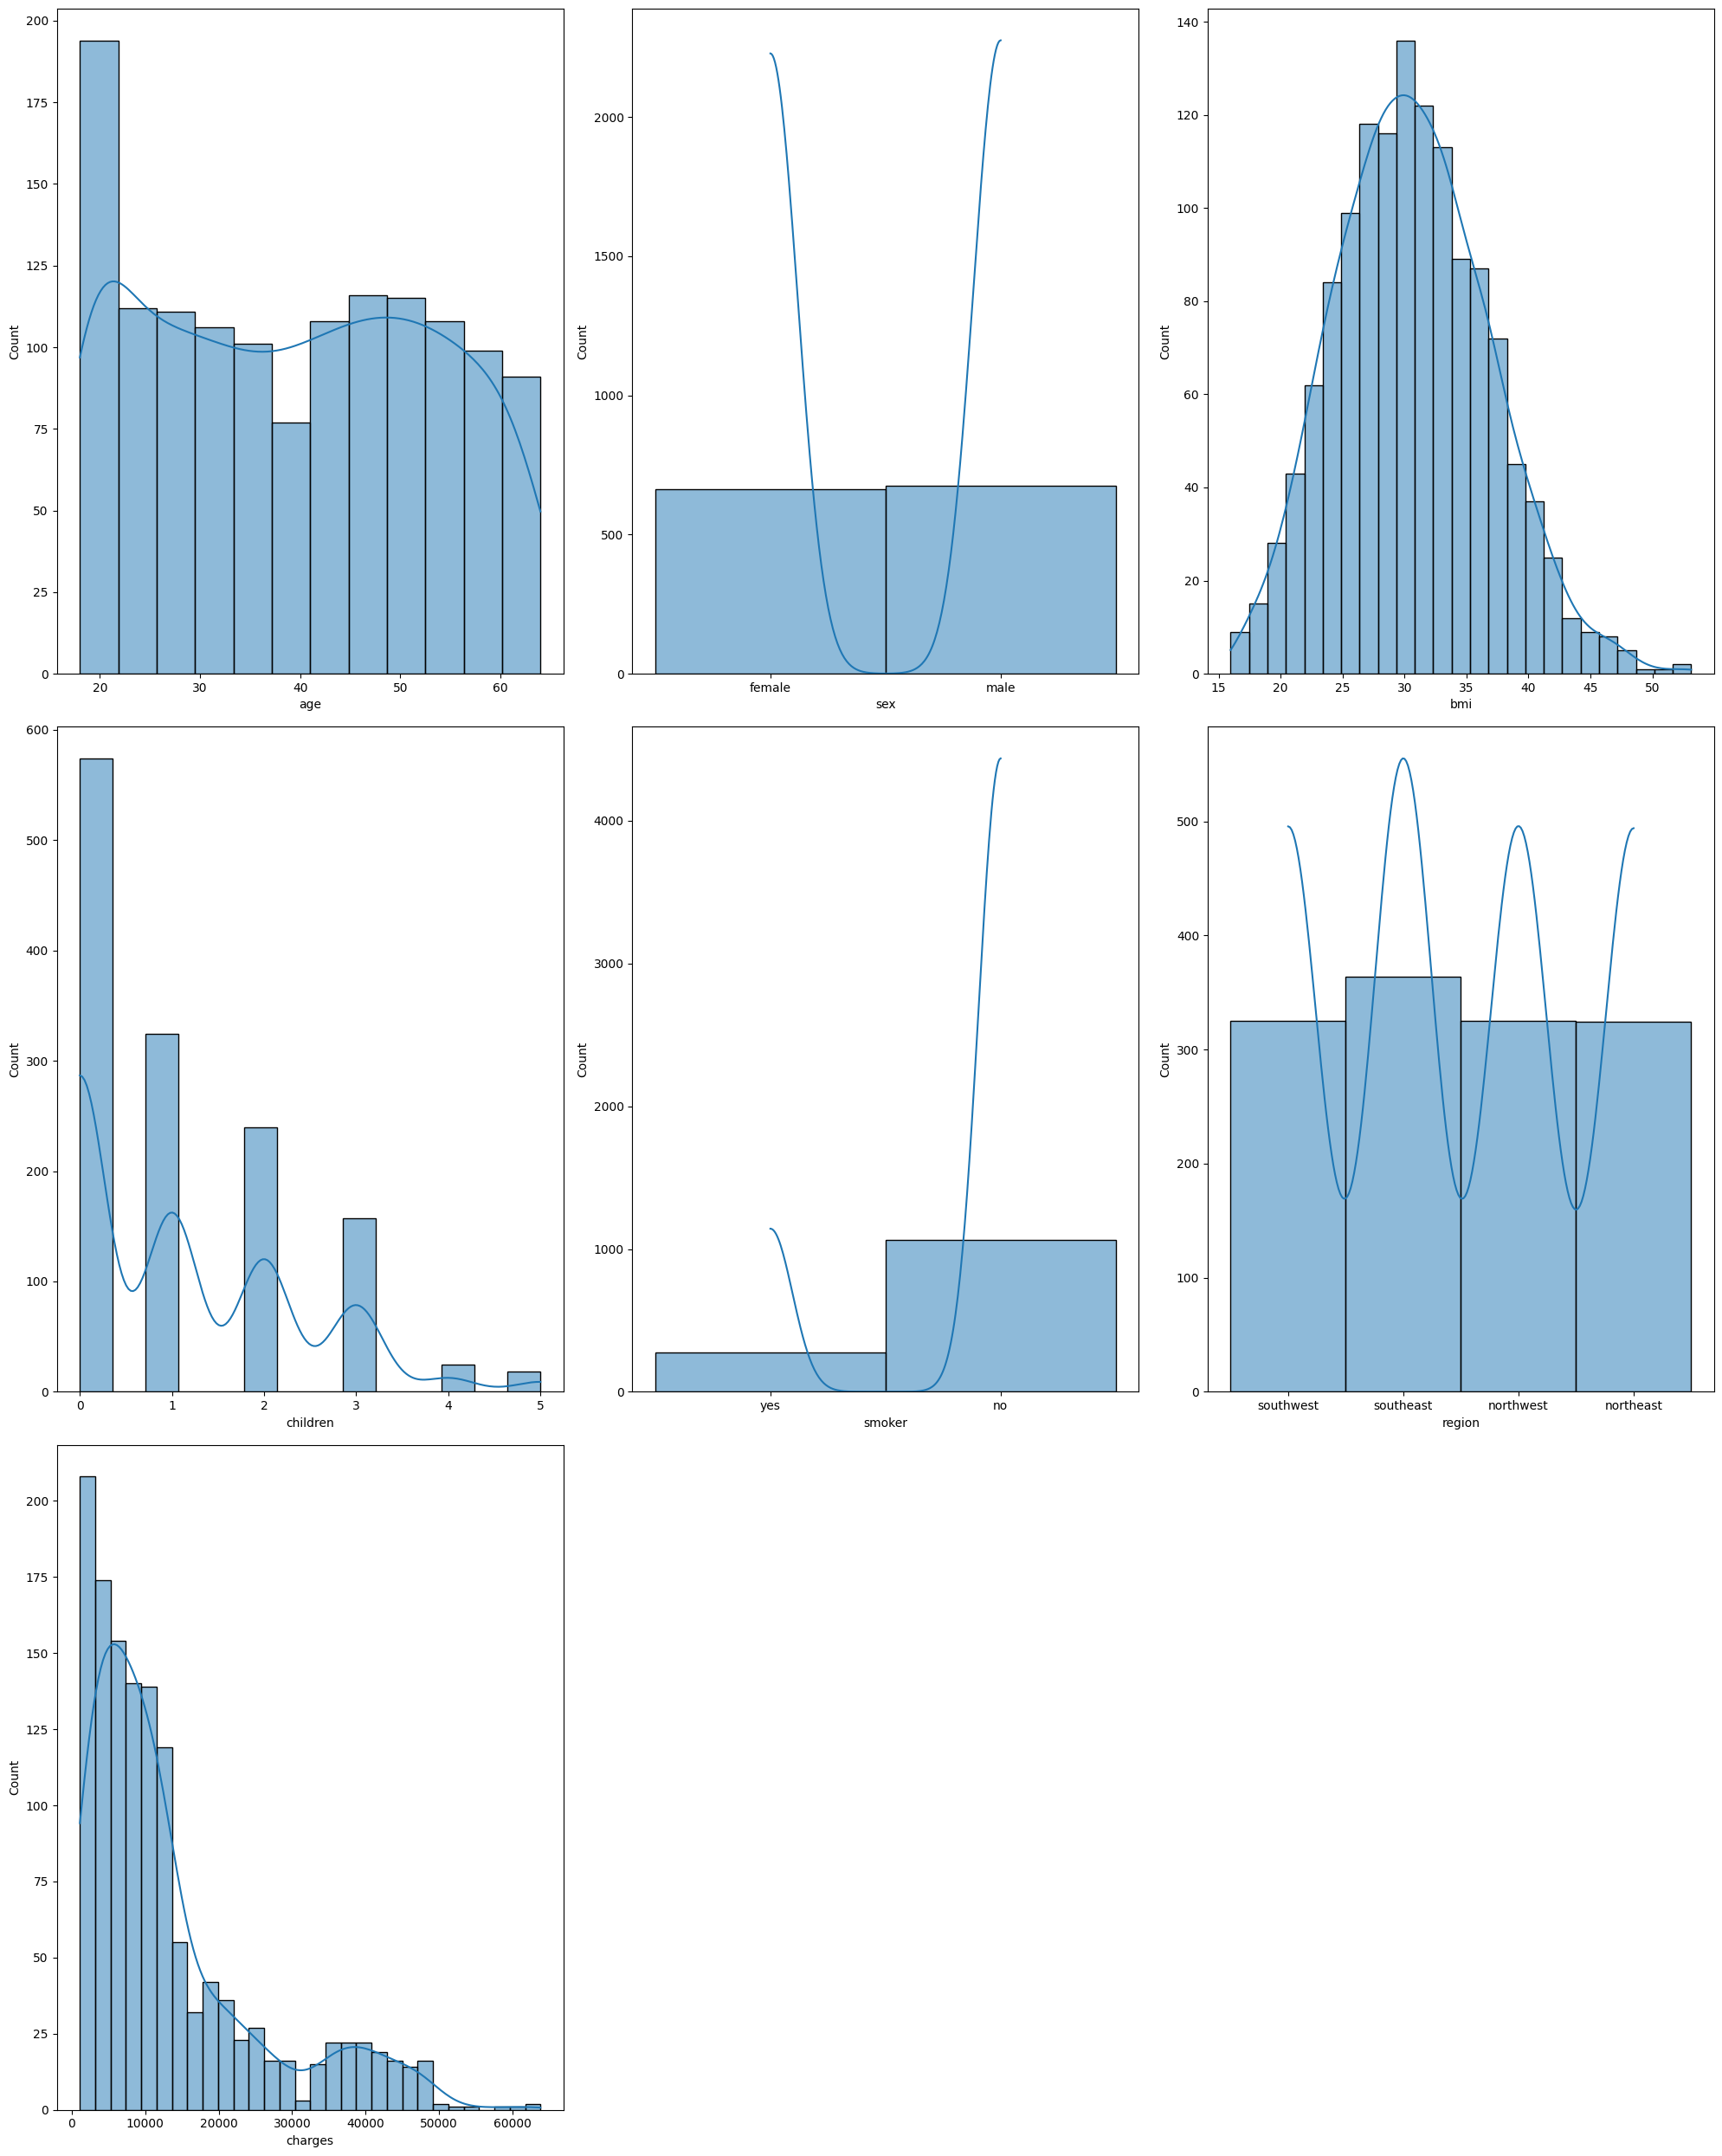

In [13]:
plotn=1
plt.figure(figsize=(20,25),facecolor='white')
for col in data.columns:
   if plotn<=7:
       ax=plt.subplot(3,3,plotn)
       sns.histplot(x=data[col],data=data,kde=True)
   plotn+=1
plt.tight_layout()
plt.show()

In [14]:
#bmi shows normal distribution 
#charges is right-skewed 

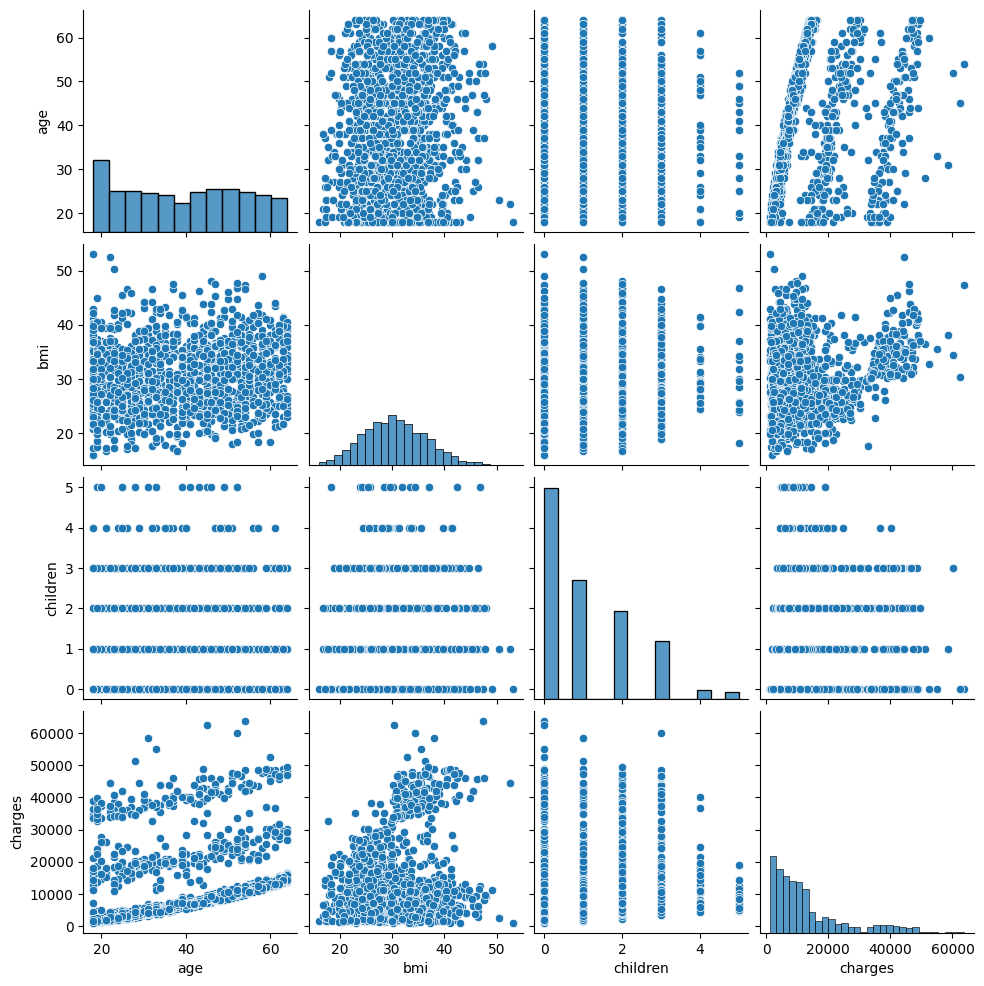

In [15]:
sns.pairplot(data)
plt.show()

# Data preprocessing

In [16]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:
#there are no null values

In [18]:
data.duplicated().sum()

1

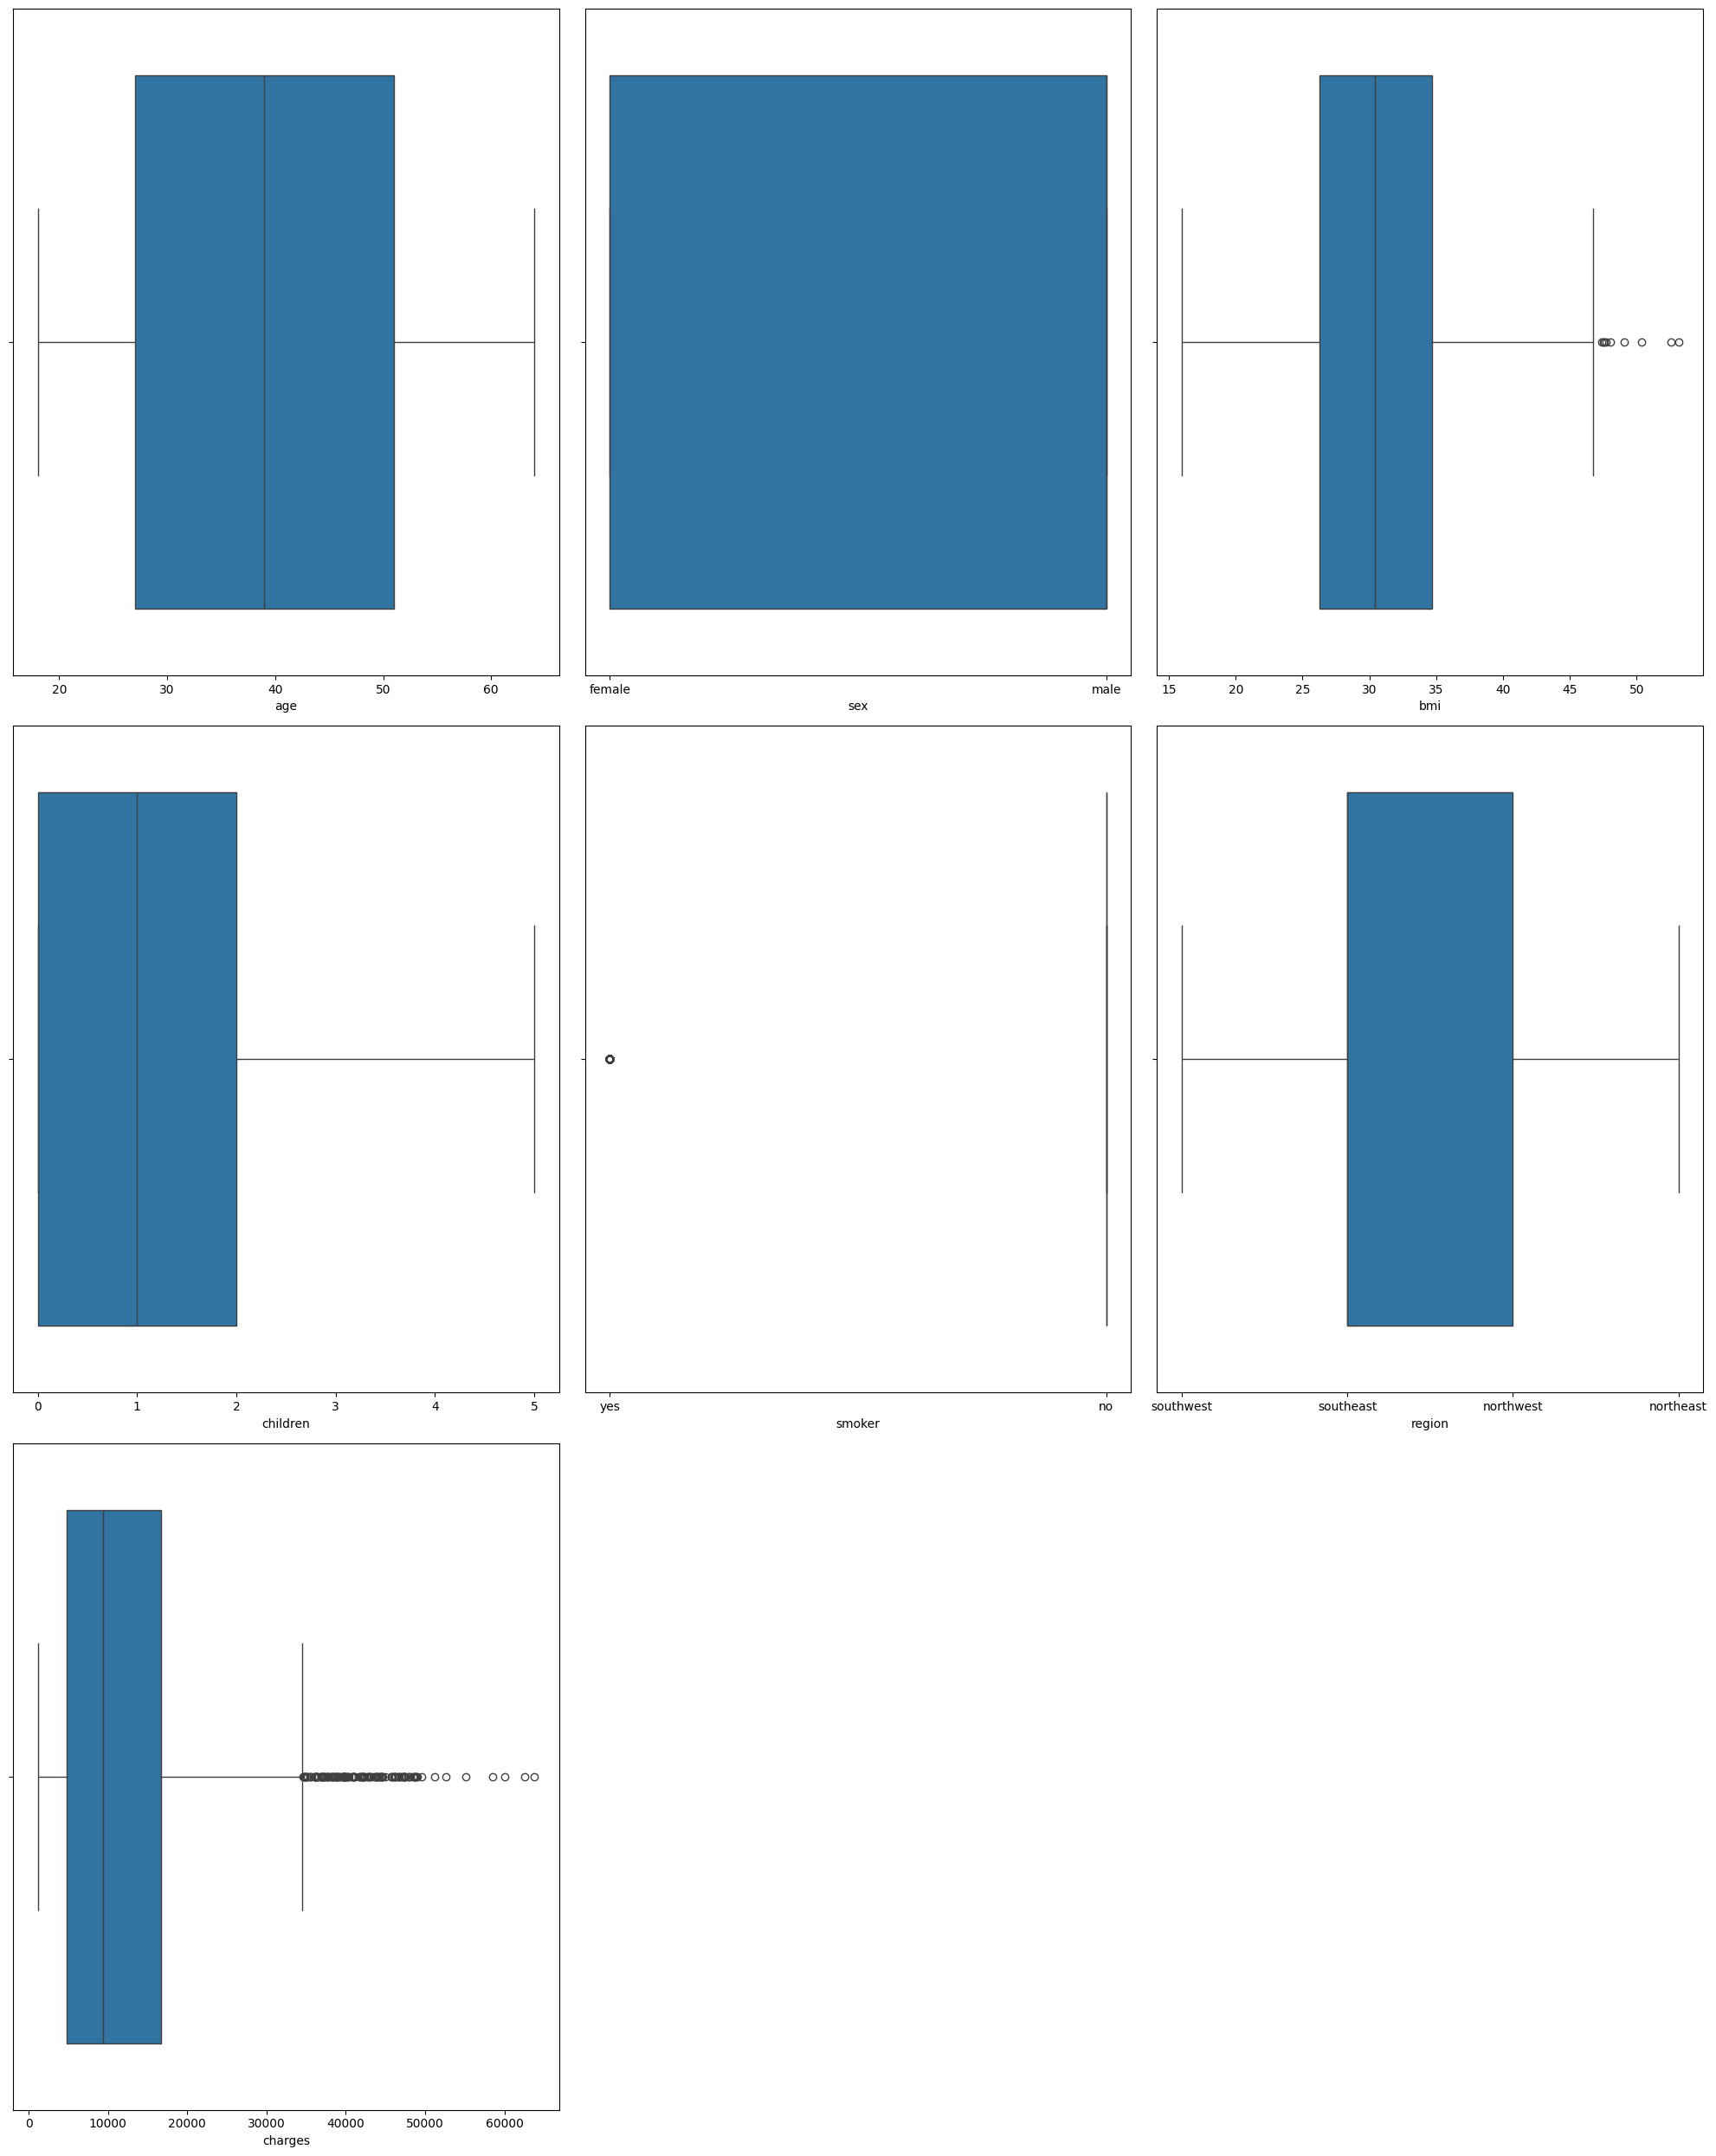

In [19]:
plotn=1
plt.figure(figsize=(20,25),facecolor='white')
for col in data.columns:
   if plotn<=7:
       ax=plt.subplot(3,3,plotn)
       sns.boxplot(x=data[col],data=data)
   plotn+=1
plt.tight_layout()
plt.show()

In [20]:
Q1 = data['bmi'].quantile(0.25)
Q3 = data['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data.loc[data['bmi']<lower,'bmi']=np.median(data.bmi)
data.loc[data['bmi']>upper,'bmi']=np.median(data.bmi)


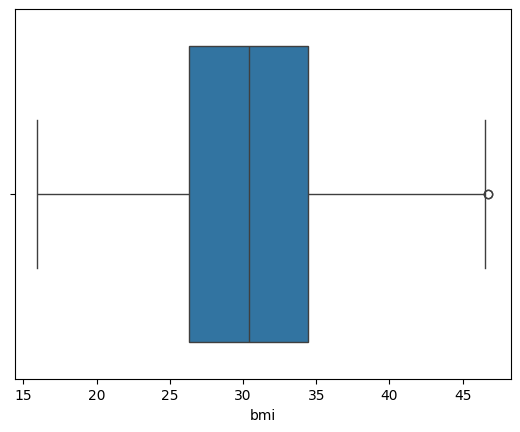

In [21]:
sns.boxplot(x=data['bmi'],data=data)
plt.show()

In [22]:
#we don't romove outliers in charges because they are more than 5% of data

In [23]:
from sklearn.preprocessing import LabelEncoder
lc=LabelEncoder()
data['sex']=lc.fit_transform(data['sex'])
data['smoker']=lc.fit_transform(data['smoker'])
data['region']=lc.fit_transform(data['region'])

# Feature selection

In [24]:
data.drop('region',axis=1,inplace=True)

In [25]:
#we droped region column because it has constant values

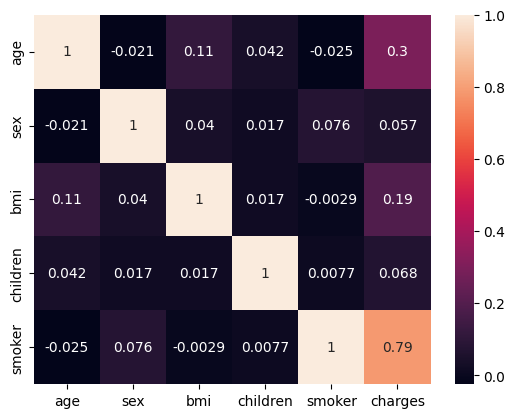

In [26]:
sns.heatmap(data.corr().drop('charges'),annot=True)
plt.show()

In [27]:
X=data.drop('charges',axis=1)
y=data.charges

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

# model creation

In [55]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,y_train)
          

LinearRegression()

In [56]:
y_pred=model.predict(X_test_scaled)

# model evaluation

In [57]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_pred)

In [58]:
r2score

0.7557465758244993

In [59]:
X_train_scaled.shape

(1003, 5)

In [60]:
## calculation of adjusted r2 score
adjusted_r2 = 1-((1-0.7557465758244993)*(1003-1)/(1003-5-1))
adjusted_r2

0.7545216338777817

In [61]:
#r2 score is less than adj.r2 score so our model is working well 

In [62]:
import math
print(mean_squared_error(y_test,y_pred))

36855677.55058375


In [63]:
print(math.sqrt(mean_squared_error(y_test,y_pred))) # root mean squared error

6070.887706965412


In [64]:
print(mean_absolute_error(y_test,y_pred))

4339.308075011319
